In [1]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_excel("income.xlsx")
df.shape

(8, 3)

In [3]:
df.head()

,Name,Age,Income (Thousands $)
0,Rob,29,45
1,Andrea,50,80
2,Mohan,35,52
3,Michael,32,41
4,Kory,36,87


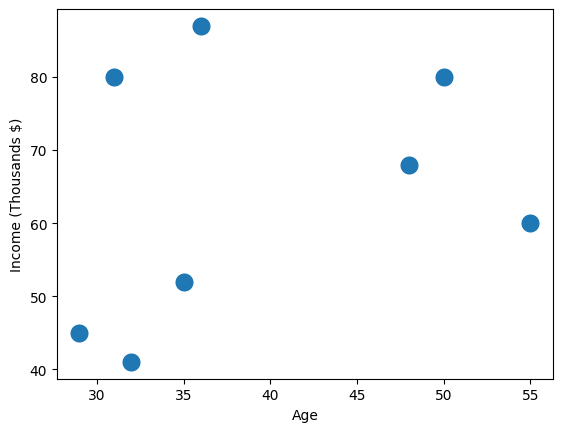

In [4]:
sns.scatterplot(df , x="Age" , y="Income (Thousands $)" , s=200)
plt.show()

### Form clusters using sklearn AgglomerativeClustering

In [5]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=2,metric='euclidean' , linkage='average')
agg.fit(df[["Age" , "Income (Thousands $)"]])
agg.labels_

array([1, 0, 1, 1, 0, 0, 0, 0])

In [6]:
df["cluster"] = agg.labels_

In [7]:
df.sample(5)

,Name,Age,Income (Thousands $),cluster
4,Kory,36,87,0
5,David,48,68,0
2,Mohan,35,52,1
3,Michael,32,41,1
7,Sheela,55,60,0


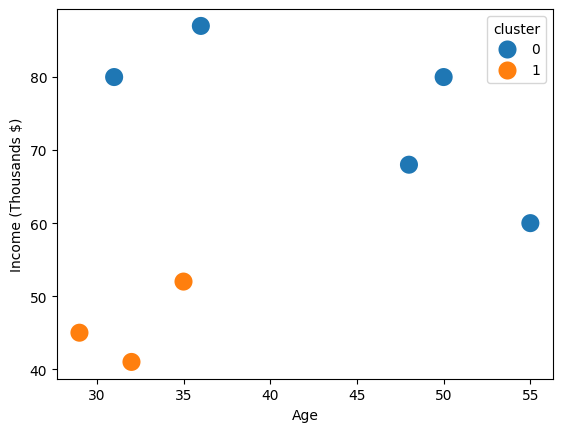

In [8]:
sns.scatterplot(df , x="Age" , y="Income (Thousands $)" , hue="cluster" , palette="tab10", s=200)
plt.show()

### Form clusters using scipy

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
X = df[["Age" , "Income (Thousands $)"]]
z = linkage(X , method="average")
z

array([[ 0.        ,  3.        ,  5.        ,  2.        ],
       [ 4.        ,  6.        ,  8.60232527,  2.        ],
       [ 2.        ,  8.        , 10.31064935,  3.        ],
       [ 5.        ,  7.        , 10.63014581,  2.        ],
       [ 1.        , 11.        , 16.39052659,  3.        ],
       [ 9.        , 12.        , 23.69824661,  5.        ],
       [10.        , 13.        , 33.65863823,  8.        ]])

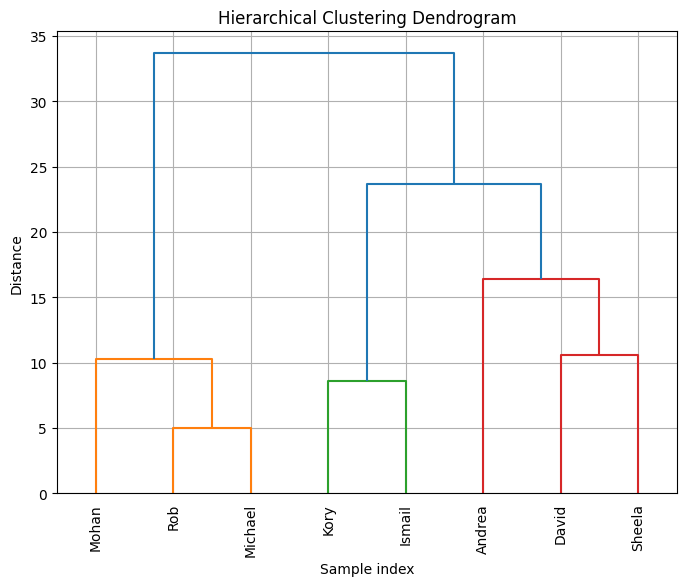

In [10]:
# Plotting the dendrogram
plt.figure(figsize=(8,6))
plt.title('Hierarchical Clustering Dendrogram')
dendrogram(z, labels=df['Name'].values, leaf_rotation=90, leaf_font_size=10)
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.grid()
plt.show()

In [11]:
clusters = fcluster(z, t=3, criterion="maxclust")
clusters

array([1, 3, 1, 1, 2, 3, 2, 3], dtype=int32)

In [12]:
df["cluster"] = clusters

In [13]:
df.head()

,Name,Age,Income (Thousands $),cluster
0,Rob,29,45,1
1,Andrea,50,80,3
2,Mohan,35,52,1
3,Michael,32,41,1
4,Kory,36,87,2


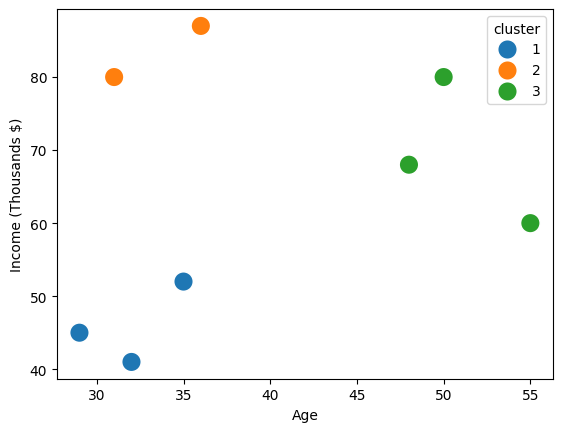

In [14]:
sns.scatterplot(df , x="Age" , y="Income (Thousands $)" , hue="cluster" , palette="tab10", s=200)
plt.show()